In [2]:
import numpy as np
import scipy.special as sp
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import scipy.optimize
import scipy.special
from sklearn.metrics import r2_score
from tqdm.notebook import tqdm
import polars as pl


def kbits(n, k):
    if k == 0:
        return 0
    limit=1<<n
    val=(1<<k)-1
    while val<limit:
        yield val
        minbit=val&-val #rightmost 1 bit
        fillbit = (val+minbit)&~val  #rightmost 0 to the left of that bit
        val = val+minbit | (fillbit//(minbit<<1))-1

def weight(x):
    """ Return weight (number of 1) of binary number """
    return x.bit_count()

def find_set_bit_positions(n):
    positions = []
    position = 0
    while n > 0:
        if n & 1:
            positions.append(position)
        n >>= 1
        position += 1
    return positions

class EvoLandscape:
    def __init__(self, L, scale=1, epistasis=1, selection_N=100, 
                 max_order=4, noise=0, selection_type='kimura', seed=None):
        """
        - scale: fitness multiplicator 
        - epistasis: each epistatic order in the fitness function is multiplied by $\left(\frac{1}{2 * epistasis}\right)^order$
        - selection_type: kimura or softmax
        - max_order: total epistatic order of the model
        - selection_N: population size N used in the kimura model
        - L: number of sites
        """
        self.L = L
        self.scale = scale
        self.max_order = max_order
        self.selection_N = selection_N
        self.rng = np.random.default_rng(seed=seed)
        self.coefficients = {}
        self.ks = {}
        self.noise = noise
        self.selection_type = selection_type
        for order in range(max_order+1):
            self.coefficients[order] = 1/(2*epistasis)**order * scale * self.rng.normal(size=int(sp.comb(L, order)))
            self.ks[order] = list(kbits(self.L, order))
            
    def fitness(self, genome, max_order=None):
        """ genome is an integer between 0 and 2^L """
        if max_order is None:
            max_order = self.max_order
        fitness = 0
        fitness = self.coefficients[0][0]
        for order in range(1, max_order+1):
            for val, k in zip(self.coefficients[order], self.ks[order]):
                fitness += (-val) * (-1)**(weight(k&genome))
        if self.noise != 0:
            return fitness + self.noise*self.rng.normal(0, 1)        
        return fitness

    def make_mutation_neutral(self, mutation_pos):
        """ Make a specific mutation neutral on all background """
        for order in range(1, self.max_order + 1):
            for ii, k in enumerate(self.ks[order]):
                if k&(1 << mutation_pos) > 0:
                    self.coefficients[order][ii] = 0


    def get_binary(self, x):
        """ Return binary array of the number """
        return "{0:0{1}b}".format(x,self.L)
    
    def evolve(self, Nsteps=15, selection_strength=1):
        genome = 0
        trajectory = [genome]
        times = [0]
        for ev in range(Nsteps):
            fitness = self.fitness(genome)
            mutants = [self.mutate(genome, ii) for ii in range(self.L)]
            fitnesses_mutants = [self.fitness(m) for m in mutants]
            probas_mutants = [self.selection(fitness, f, selection_strength=selection_strength) for f in fitnesses_mutants]
            proba_stay = 1 - np.sum(probas_mutants)
            if np.sum(probas_mutants) == 0 or not np.isfinite(np.sum(probas_mutants)):
                return trajectory
            genome = self.rng.choice(mutants, p=probas_mutants/np.sum(probas_mutants))
            trajectory += [genome]
        return trajectory

    def log10_probability_path(self, path):
        log_likelihood = 0
        for prv, nxt in zip(path[:-1], path[1:]):
            fitness_prv = self.fitness(prv)
            mutants = [self.mutate(prv, ii) for ii in range(self.L)]
            if nxt not in mutants:
                raise Exception("The path is not well defined")
            fitnesses_mutants = [self.fitness(m) for m in mutants]
            probas_mutants = [self.selection(fitness_prv, f) for f in fitnesses_mutants]
            log_likelihood += np.log10(self.selection(fitness_prv, self.fitness(nxt)) / np.sum(probas_mutants))
        return log_likelihood
            
    def epistasis_average(self, mutations_considered):
        """ Return the epistasis coeffcients over a "reduced" number of mutations """
        # make a mask with 1 on the moving coef
        mask = 0
        for c in mutations_considered:
            mask = self.mutate(mask, c)
        coefs = {}
        for order in range(self.max_order + 1):
            coefs[order] = {}
            for val, k in zip(self.coefficients[order], self.ks[order]):
                res = k&mask
                new_order = weight(res)
                coefs[new_order][res] = val if res not in coefs[new_order] else (coefs[new_order][res] + val)
        return coefs

    def mutations_positions(self, genome):
        return set(find_set_bit_positions(genome))

    def mutate(self, genome, ii):
        # Create a mask with a 1 at the i-th position
        mask = 1 << ii
        # XOR the number with the mask to flip the i-th bit
        return genome ^ mask

    def selection(self, f_current, f_next, selection_strength=1):
        if self.selection_type == 'kimura':
            if self.selection_N * (f_next - f_current) < -200: # avoid the overflow, but not perfect
                return 0.
            if self.selection_N * (f_next - f_current) > 200:
                return 1.
            return (1/self.L
                    * np.expm1(-2*selection_strength*(f_next - f_current)) 
                    / np.expm1(-2*selection_strength*self.selection_N*(f_next - f_current)))
        elif self.selection_type == 'softmax':
            return np.exp(2*selection_strength*(f_next - f_current))

        
    def all_combinatorial_positions(self, positions):
        # Ensure positions are unique
        positions = list(set(positions))
        m = len(positions)
        numbers = []
        for c in range(2**m):
            result = 0
            for j in range(m):
                if (c >> j) & 1:
                    result += 2**positions[j]
            numbers.append(result)
        return sorted(numbers)

    def estimate_se_coefficients(self, genotypes, phenotypes, max_order):
        """ Given a list of fitness values for genotypes (integer), estimate the coefficients
        of the statistical epistasis model. """
        poly = PolynomialFeatures(max_order, interaction_only=True)
        geno = poly.fit_transform([[2*int(a) - 1 for a in f'{b:0{self.L}b}'] for b in genotypes])
        result_opt = scipy.linalg.lstsq(geno, phenotypes)
        res = result_opt[0]
        # measure the r2
        r2 = r2_score(phenotypes, geno @ res)
        return res, geno@res, r2

    

def hamming_distance(x, y):
    return bin(x^y).count('1')

In [137]:
L = 10
Nsteps = 5
r2s = []
for rr in tqdm(range(10)):
    traj = {}
    distance_to_real = {}
    el = EvoLandscape(L=L, epistasis=2, scale=50, max_order=5, noise=1)
    genotypes = range(2**L)
    phenotypes = [el.fitness(g) for g in genotypes]
    for max_order in range(0, 6):
        _, _, r2 = el.estimate_se_coefficients(genotypes, phenotypes, max_order)
        r2s += [{'r2': r2, 'order_model': max_order, 'replicate': rr}]

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_35246/1398539296.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


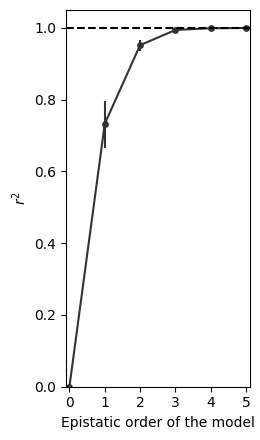

In [383]:

df = pl.DataFrame(r2s)
fig, ax = plt.subplots(figsize=(2.7, 4.5))
sns.pointplot(x='order_model', c='#333333', y='r2', data=df, ax=ax, linewidth=1.5)
ax.set_xlabel('Epistatic order of the model')
ax.set_ylabel('$r^2$')
#inset_ax = ax.inset_axes([0.4, 0.1, 0.55, 0.6])
#sns.pointplot(x='order_model', y='r2', c='k', data=df.filter(pl.col('order_model') >= 2), ax=inset_ax, linewidth=2)
#inset_ax.set_yscale("logit")
#inset_ax.set_xlabel('')
#inset_ax.set_ylim(0.9, 0.9999)
#inset_ax.set_ylabel('')
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.1, 5.1)
ax.axhline(y=1, linestyle='--', c='k')
plt.tight_layout()
fig.savefig('fig_why_epistasis_A.png', dpi=600)
fig.show()

In [355]:
L = 12
Nsteps = 5
trajs = []
for rr in tqdm(range(500)):
    traj = {}
    distance_to_real = {}
    el = EvoLandscape(L=L, epistasis=2, scale=50, max_order=5, selection_type='softmax', noise=5)
    base = el.evolve(Nsteps=Nsteps)
    traj['5'] = el.evolve(Nsteps=Nsteps)
    el.coefficients[5] = 0  * el.coefficients[5]
    traj['4'] = el.evolve(Nsteps=Nsteps)
    el.coefficients[4] = 0  * el.coefficients[4]
    traj['3'] = el.evolve(Nsteps=Nsteps)
    el.coefficients[3] = 0  * el.coefficients[3]
    traj['2'] = el.evolve(Nsteps=Nsteps)
    el.coefficients[2] = 0  * el.coefficients[2]
    traj['1'] = el.evolve(Nsteps=Nsteps)
    el.coefficients[1] = 0  * el.coefficients[1]
    traj['0'] = el.evolve(Nsteps=Nsteps)
    for kk in range(0, 6):
        for ll in range(1, 6):
            trajs += [{'replicate': rr, 'epistatis_order': kk, 'step': ll, 'distance': hamming_distance(traj[str(kk)][ll], base[ll])}]

  0%|          | 0/500 [00:00<?, ?it/s]

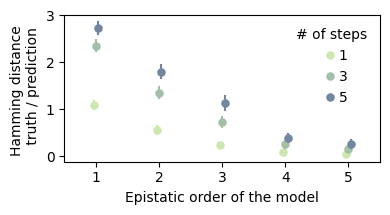

In [382]:
custom_colors = ["#CDE7B0", "#A3BFA8", "#7286A0"]
custom_palette = sns.color_palette(custom_colors)
#sns.palplot(custom_palette)
df = pl.DataFrame(trajs)
fig, ax = plt.subplots(figsize=(4, 2.25))
df = df.rename({'step': '# of steps'})
sns.pointplot(x='epistatis_order', y='distance', hue='# of steps', palette=custom_palette, dodge=True,
              data=df.filter(pl.col('# of steps').is_in([1,3,5])).filter(pl.col('epistatis_order') > 0),
              ax=ax, linewidth=1.5, linestyle='none', markersize=5)
ax.set_xlabel('Epistatic order of the model')
ax.set_ylabel('Hamming distance \n truth / prediction')
plt.legend(title="# of steps", frameon=False, handletextpad=-0.4)
plt.tight_layout()
plt.savefig('fig_why_epistasis_B.png', dpi=600)

In [357]:
L = 12
Nsteps = 5
probs = []
for rr in tqdm(range(500)):
    prob = {}
    el = EvoLandscape(L=L, epistasis=2, scale=50, max_order=5, selection_type='softmax', noise=5)
    base = el.evolve(Nsteps=Nsteps)
    for kk in range(5, 0, -1): 
        prob[kk] = el.log10_probability_path(base)
        el.coefficients[kk] = 0  * el.coefficients[kk]
    for kk in range(1, 6):
        probs += [{'replicate': rr, 'epistatis_order': kk, 'proba': prob[kk], 'with_noise':True}]

    el = EvoLandscape(L=L, epistasis=2, scale=50, max_order=5, selection_type='softmax', noise=0)
    base = el.evolve(Nsteps=Nsteps)
    for kk in range(5, 0, -1): 
        prob[kk] = el.log10_probability_path(base)
        el.coefficients[kk] = 0  * el.coefficients[kk]
    for kk in range(1, 6):
        probs += [{'replicate': rr, 'epistatis_order': kk, 'proba': prob[kk], 'with_noise':False}]
        


    

  0%|          | 0/500 [00:00<?, ?it/s]

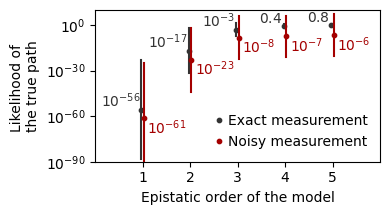

In [385]:


custom_colors = ["#333333", "#a40000"]
custom_palette = sns.color_palette(custom_colors)
#sns.palplot(custom_palette)
df = pl.DataFrame(probs)
df = df.with_columns(
    likelihood=pl.lit(10).pow(pl.col('proba')),
    noise_like = pl.when(pl.col('with_noise')).then(pl.lit('Noisy measurement')).otherwise(pl.lit('Exact measurement')))
fig, ax = plt.subplots(figsize=(4, 2.25))
sns.pointplot(x='epistatis_order', y='likelihood', hue='noise_like', log_scale=True,
              hue_order=['Exact measurement', 'Noisy measurement'], dodge=True,
              data=df, ax=ax, linewidth=1.5, linestyle='none', 
              markersize=3, errorbar='sd', palette=custom_palette)
ax.set_xlabel('Epistatic order of the model')
ax.set_ylabel('Likelihood of \nthe true path')
ax.set_ylim(1e-90, 1e10)
ax.set_xlim(-1, 5)
ax.legend()
ax.set_yticks([1e-90, 1e-60, 1e-30, 1])
#ax.set_ticks([1e-90, 1e-60, 1e-30, 1])
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles=handles[1:], labels=labels[1:])
plt.legend(frameon=False, handletextpad=-0.4)

for r in df.filter(pl.col('with_noise')).group_by(['epistatis_order']).agg(pl.col('proba').mean()).rows(named=True):
    ax.text(r['epistatis_order']-1 + 0.1, 10**r['proba'], 
            f"$10^{{{int(round(r['proba']))}}}$" if r['proba'] < -2 else f"${10**r['proba']:.1}$",
            ha='left', va='top', c=custom_colors[1])
    
for r in df.filter(~pl.col('with_noise')).group_by(['epistatis_order']).agg(pl.col('proba').mean()).rows(named=True):
    ax.text(r['epistatis_order']-1 - 0.05, 10**r['proba'], 
            f"$10^{{{int(round(r['proba']))}}}$" if r['proba'] < -2 else f"${10**r['proba']:.1}$",
            ha='right', va='bottom', c=custom_colors[0])

plt.tight_layout()
plt.savefig('fig_why_epistasis_C.png', dpi=600)

# With real data

In [3]:
df = pl.read_csv("20210427_HA_unadj_fil_merg.csv", schema_overrides={'variant':pl.String})
df = df.drop_nulls(['variant', 'h1_mean'])
# impute real phenotypes
L = 16
# empty evolution model, fit a 7th order model on it
el_real = EvoLandscape(L=L, epistasis=1, scale=0, max_order=7)
genotypes = df['variant'].map_elements(lambda x: int(x,2), return_dtype=int).to_numpy()
phenotypes = df['h1_mean'].to_numpy()


In [ ]:
coefs, est_pheno, r2 = el_real.estimate_se_coefficients(genotypes, phenotypes, 7)

In [ ]:
r2s_real = []
for max_order in range(0, 7):
    genotypes = range(2**L)
    phenotypes = [df.filter(pl.col('variant') == f"{k:016b}")['h1_mean'][0] for k in genotypes]
    _, _, r2 = el_real.estimate_se_coefficients(genotypes, phenotypes, max_order)
    r2s_real += [{'r2': r2, 'order_model': max_order}]

In [ ]:
L = 12
Nsteps = 5
probs_real = []
for rr in tqdm(range(50)):
    prob = {}
    base = el_real.evolve(Nsteps=Nsteps)
    for kk in range(5, 0, -1): 
        prob[kk] = el_real.log10_probability_path(base)
        el.coefficients[kk] = 0  * el.coefficients[kk]
    for kk in range(1, 6):
        probs_real += [{'replicate': rr, 'epistatis_order': kk, 'proba': prob[kk], 'with_noise':True}]

    el_real_noise = el_real.copy()
    el_real_noise.noise = 0.1
    base = el.evolve(Nsteps=Nsteps)
    for kk in range(5, 0, -1): 
        prob[kk] = el.log10_probability_path(base)
        el.coefficients[kk] = 0  * el.coefficients[kk]
    for kk in range(1, 6):
        probs += [{'replicate': rr, 'epistatis_order': kk, 'proba': prob[kk], 'with_noise':False}]
        


    